# YOLOv8m Object Detection Model Evaluation

This notebook evaluates the YOLOv8m object detection model trained with class imbalance weighting and augmentation.
- **Model**: face_mask_detection_yolov8m_v2_best.pt
- **Purpose**: Detect faces and classify mask status (detection + classification combined)
- **Evaluation**: Metric on test set using ground truth annotations

## Setup and Imports

In [21]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## Define Paths and Load Model

### How to Calculate Model Parameters

**Formula for Dense/Fully Connected Layers:**
```
Parameters = (input_size × output_size) + output_size
           = (input_size × output_size) + bias_terms
```

**Example: Dense(256) after 1280 inputs:**
```
Parameters = (1280 × 256) + 256 = 327,936
```

**Formula for Convolutional Layers:**
```
Parameters = (kernel_height × kernel_width × input_channels × output_channels) + output_channels
```

**Example: Conv2D(3×3, input=32, output=64):**
```
Parameters = (3 × 3 × 32 × 64) + 64 = 18,496
```

**Formula for Batch Normalization:**
```
Parameters = 2 × num_features  (scale + shift parameters)
           + 2 × num_features  (running mean + variance, not trainable)
```

**Example: BatchNorm(256 features):**
```
Parameters = 2 × 256 = 512 (trainable)
```

**Layers with NO Parameters:**
- Activation layers (ReLU, Sigmoid, etc.)
- Dropout layers
- GlobalAveragePooling layers
- Max/Average Pooling layers

In [22]:
# Define paths
BASE_DIR = Path('/Users/khoanguyen/Workspace/UIT/face_mask_detection')
MODEL_PATH = BASE_DIR / 'models' / 'face_mask_detection_yolov8m_v2_best.pt'
TEST_IMAGES_DIR = BASE_DIR / 'datasets' / 'face-mask-detection-processed' / 'images' / 'test'
TEST_LABELS_DIR = BASE_DIR / 'datasets' / 'face-mask-detection-processed' / 'labels' / 'test'

# Class names
CLASS_NAMES = ['With Mask', 'Without Mask', 'Mask Weared Incorrect']

print(f"Model path: {MODEL_PATH}")
print(f"Model exists: {MODEL_PATH.exists()}")
print(f"Test images directory exists: {TEST_IMAGES_DIR.exists()}")
print(f"Test labels directory exists: {TEST_LABELS_DIR.exists()}")

Model path: /Users/khoanguyen/Workspace/UIT/face_mask_detection/models/face_mask_detection_yolov8m_v2_best.pt
Model exists: True
Test images directory exists: True
Test labels directory exists: True


In [23]:
# Load YOLO model
print("Loading YOLOv8m detection model...")
model = YOLO(str(MODEL_PATH))
print("Model loaded successfully!")
print(f"\nModel info:")
print(f"Model type: {type(model)}")

# Get model parameters
total_params = sum(p.numel() for p in model.model.parameters())
trainable_params = sum(p.numel() for p in model.model.parameters() if p.requires_grad)

print(f"\nTotal Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

print(f"\nModel Architecture Summary:")
model.info()

Loading YOLOv8m detection model...
Model loaded successfully!

Model info:
Model type: <class 'ultralytics.models.yolo.model.YOLO'>

Total Parameters: 25,858,057
Trainable Parameters: 0

Model Architecture Summary:
Model summary: 170 layers, 25,858,057 parameters, 0 gradients, 79.1 GFLOPs


(170, 25858057, 0, 79.0720512)

In [24]:
# Create YOLOv8 model info summary
print("\n" + "="*100)
print("YOLOV8M MODEL ARCHITECTURE DETAILS")
print("="*100)

# Get model layers info
model_info = []
for i, module in enumerate(model.model.model):
    try:
        module_name = module.__class__.__name__
        if hasattr(module, 'in_channels'):
            in_ch = module.in_channels if hasattr(module, 'in_channels') else 'N/A'
            out_ch = module.out_channels if hasattr(module, 'out_channels') else 'N/A'
            info_str = f"{module_name} (in: {in_ch}, out: {out_ch})"
        else:
            info_str = module_name
        
        params = sum(p.numel() for p in module.parameters()) if hasattr(module, 'parameters') else 0
        model_info.append({
            'Layer #': i,
            'Module (type)': info_str,
            'Param #': f"{params:,}"
        })
    except:
        pass

if model_info:
    model_df = pd.DataFrame(model_info)
    print(model_df.to_string(index=False))

print("="*100)
print(f"\nTotal Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")


YOLOV8M MODEL ARCHITECTURE DETAILS
 Layer # Module (type)   Param #
       0          Conv     1,392
       1          Conv    41,664
       2           C2f   111,360
       3          Conv   166,272
       4           C2f   813,312
       5          Conv   664,320
       6           C2f 3,248,640
       7          Conv 1,991,808
       8           C2f 3,985,920
       9          SPPF   831,168
      10      Upsample         0
      11        Concat         0
      12           C2f 1,993,728
      13      Upsample         0
      14        Concat         0
      15           C2f   517,632
      16          Conv   332,160
      17        Concat         0
      18           C2f 1,846,272
      19          Conv 1,327,872
      20        Concat         0
      21           C2f 4,207,104
      22        Detect 3,777,433

Total Parameters: 25,858,057
Trainable Parameters: 0


## Data Preparation

In [25]:
# Get test images
test_images = sorted(list(TEST_IMAGES_DIR.glob('*.jpg')) + list(TEST_IMAGES_DIR.glob('*.png')))
print(f"Found {len(test_images)} test images")

# Function to read YOLO format labels
def read_yolo_label(label_path):
    """Read YOLO format label file and return list of (class_id, bbox_center_x, bbox_center_y, bbox_w, bbox_h)"""
    labels = []
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    bbox = [float(x) for x in parts[1:]]
                    labels.append((class_id, *bbox))
    return labels

print("Helper functions defined")
print(f"Sample test images:")
for img in test_images[:3]:
    print(f"  {img.name}")

Found 578 test images
Helper functions defined
Sample test images:
  0020.jpg
  0049.jpg
  0054.jpg


## Model Evaluation

In [26]:
# Run predictions on test set
print("Running YOLOv8m predictions on test set...")

y_true = []
y_pred = []
confidences = []

for img_path in tqdm(test_images):
    # Get ground truth labels
    label_path = TEST_LABELS_DIR / (img_path.stem + '.txt')
    gt_labels = read_yolo_label(label_path)
    
    # Run YOLO prediction
    results = model(str(img_path), verbose=False)
    
    # Extract predictions
    for result in results:
        boxes = result.boxes
        if boxes is not None and len(boxes) > 0:
            for box in boxes:
                pred_class = int(box.cls[0])
                confidence = float(box.conf[0])
                y_pred.append(pred_class)
                confidences.append(confidence)
    
    # Extract ground truth (one label per detection)
    for gt_class, _, _, _, _ in gt_labels:
        y_true.append(gt_class)

# Handle case where number of predictions doesn't match ground truth
min_len = min(len(y_true), len(y_pred))
y_true = y_true[:min_len]
y_pred = y_pred[:min_len]
confidences = confidences[:min_len]

print(f"\nTotal predictions: {len(y_pred)}")
print(f"Total ground truth: {len(y_true)}")

Running YOLOv8m predictions on test set...


100%|██████████| 578/578 [00:11<00:00, 48.65it/s]


Total predictions: 1393
Total ground truth: 1393


## Calculate Metrics

In [27]:
# Calculate overall metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

# Per-class metrics
precision_per_class = precision_score(y_true, y_pred, average=None, zero_division=0)
recall_per_class = recall_score(y_true, y_pred, average=None, zero_division=0)
f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=0)

print("\n" + "="*80)
print("YOLOV8M MODEL - OVERALL METRICS")
print("="*80)
print(f"Accuracy:        {accuracy:.4f}")
print(f"Precision:       {precision:.4f}")
print(f"Recall:          {recall:.4f}")
print(f"F1-Score:        {f1:.4f}")
print(f"Avg Confidence:  {np.mean(confidences):.4f}")

print("\n" + "="*80)
print("PER-CLASS METRICS")
print("="*80)
for i, class_name in enumerate(CLASS_NAMES):
    if i < len(precision_per_class):
        print(f"\n{class_name}:")
        print(f"  Precision: {precision_per_class[i]:.4f}")
        print(f"  Recall:    {recall_per_class[i]:.4f}")
        print(f"  F1-Score:  {f1_per_class[i]:.4f}")


YOLOV8M MODEL - OVERALL METRICS
Accuracy:        0.7344
Precision:       0.7322
Recall:          0.7344
F1-Score:        0.7330
Avg Confidence:  0.6547

PER-CLASS METRICS

With Mask:
  Precision: 0.8389
  Recall:    0.8336
  F1-Score:  0.8363

Without Mask:
  Precision: 0.3650
  Recall:    0.4049
  F1-Score:  0.3839

Mask Weared Incorrect:
  Precision: 0.0500
  Recall:    0.0250
  F1-Score:  0.0333


## Visualizations

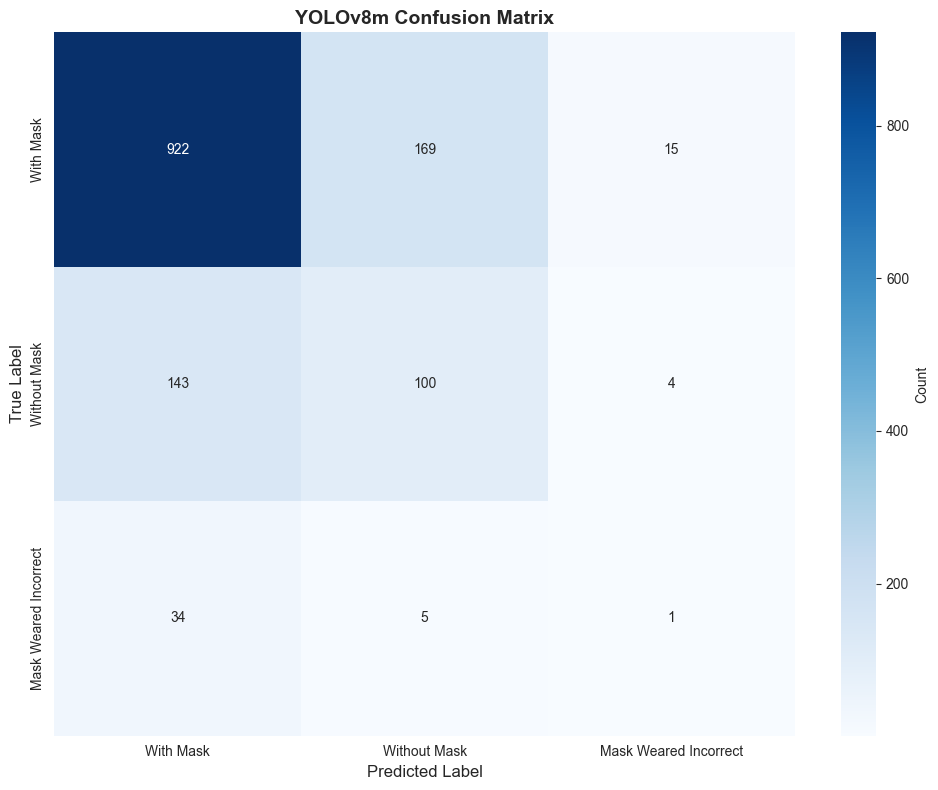

In [28]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'Count'})
ax.set_title('YOLOv8m Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

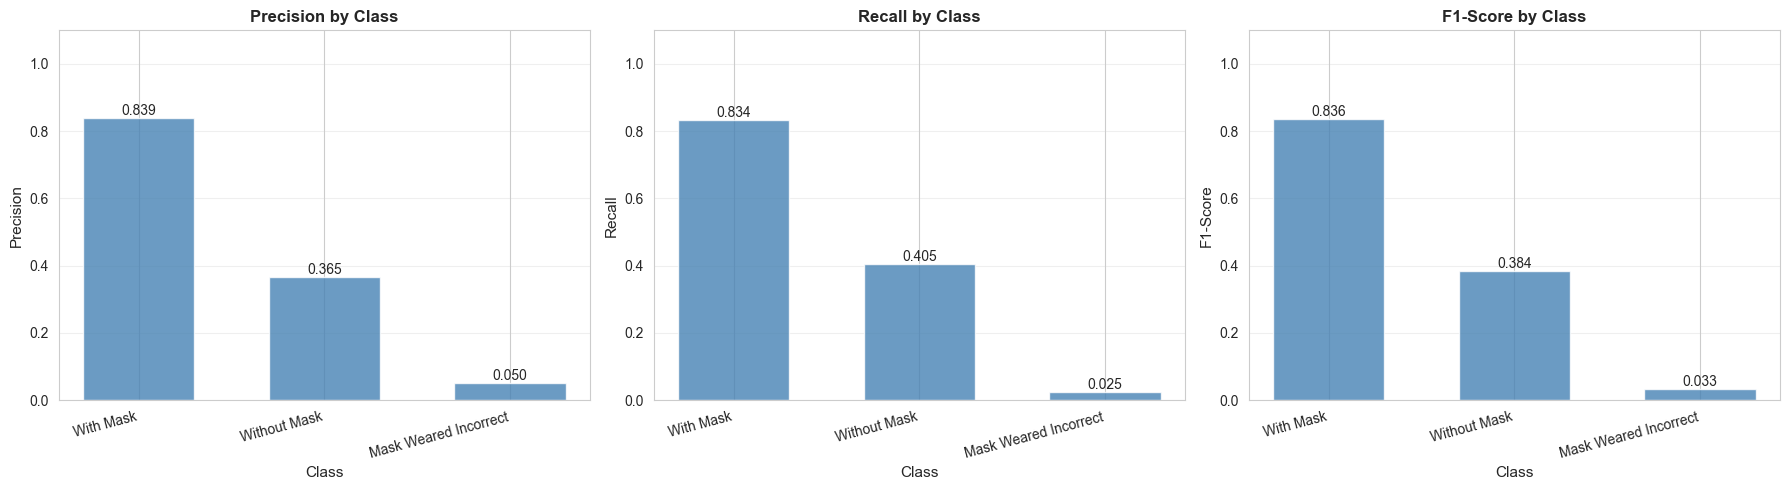

In [29]:
# Per-class metrics visualization
metrics_names = ['Precision', 'Recall', 'F1-Score']
metrics_values = [precision_per_class, recall_per_class, f1_per_class]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (metric_name, metric_vals) in enumerate(zip(metrics_names, metrics_values)):
    ax = axes[idx]
    x = np.arange(len(CLASS_NAMES))
    width = 0.6
    
    # Ensure all classes are represented
    plot_vals = np.zeros(len(CLASS_NAMES))
    for i in range(len(CLASS_NAMES)):
        if i < len(metric_vals):
            plot_vals[i] = metric_vals[i]
    
    bars = ax.bar(x, plot_vals, width, alpha=0.8, color='steelblue')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10)
    
    ax.set_xlabel('Class', fontsize=11)
    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_title(f'{metric_name} by Class', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

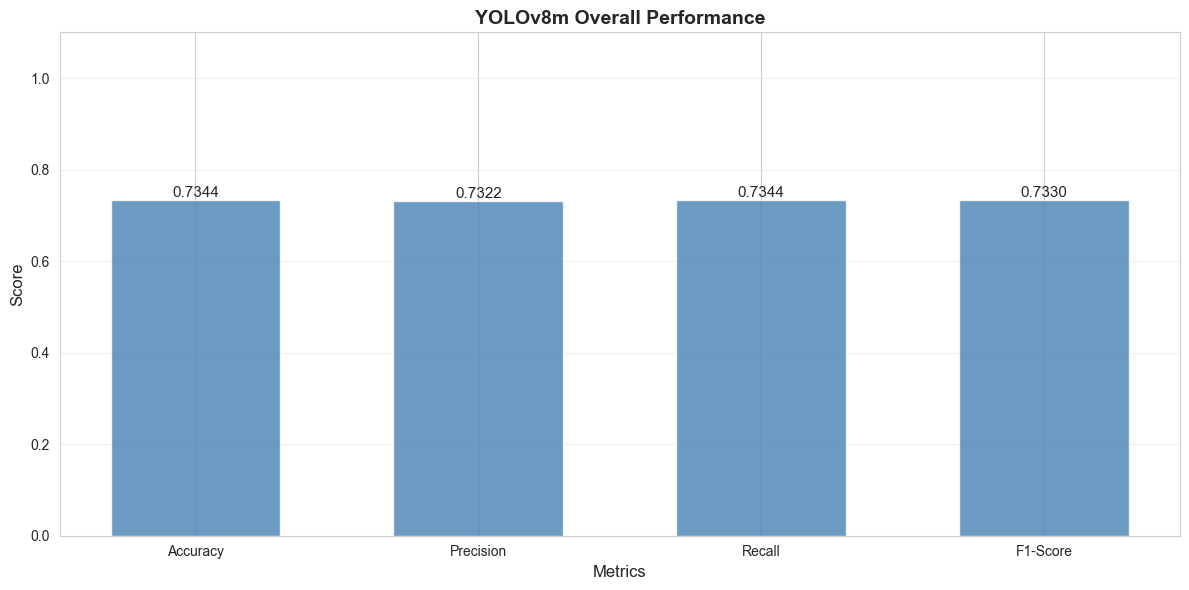

In [30]:
# Overall metrics bar chart
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [accuracy, precision, recall, f1]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics_names))
width = 0.6

bars = ax.bar(x, metrics_values, width, alpha=0.8, color='steelblue')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=11)

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('YOLOv8m Overall Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

## Detailed Classification Report

In [31]:
print("\n" + "="*80)
print("YOLOV8M CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))


YOLOV8M CLASSIFICATION REPORT
                       precision    recall  f1-score   support

            With Mask       0.84      0.83      0.84      1106
         Without Mask       0.36      0.40      0.38       247
Mask Weared Incorrect       0.05      0.03      0.03        40

             accuracy                           0.73      1393
            macro avg       0.42      0.42      0.42      1393
         weighted avg       0.73      0.73      0.73      1393

